In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys

sns.set_theme(style="whitegrid", palette="pastel")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

sys.path.append('../logic')

# Data Preprocessing

Based on new insights and on information extracted from the data understanding phase, we now move to the data preprocessing stage, where we'll prepare the data for our prediction tasks.

In [2]:
awards_players_df = pd.read_csv('../datasets/awards_players.csv')
coaches_df        = pd.read_csv('../datasets/coaches.csv')
players_teams_df  = pd.read_csv('../datasets/players_teams.csv')
players_df        = pd.read_csv('../datasets/players.csv')
series_post_df    = pd.read_csv('../datasets/series_post.csv')
teams_post_df     = pd.read_csv('../datasets/teams_post.csv')
teams_df          = pd.read_csv('../datasets/teams.csv')

## Data Cleaning

In [3]:
coaches_df.drop(columns=['lgID'], inplace=True)
awards_players_df.drop(columns=['lgID'], inplace=True)
players_teams_df.drop(columns=['lgID'], inplace=True)
players_df.drop(columns=['firstseason', 'lastseason', 'deathDate', 'collegeOther'], inplace=True)
series_post_df.drop(columns=['lgIDWinner', 'lgIDLoser'], inplace=True)
teams_post_df.drop(columns=['lgID'], inplace=True)
teams_df.drop(columns=['lgID', 'divID', 'franchID', 'seeded', 'tmORB', 'tmDRB', 'tmTRB', 'opptmORB', 'opptmDRB', 'opptmTRB'], inplace=True)

### Players Dataset

Identify and remove player entries with no actual game data:

In [4]:
# Find players with empty data
empty_players = players_df[
    (players_df['height'] == 0) & 
    (players_df['weight'] == 0) & 
    (players_df['pos'].isna()) &
    (players_df['birthDate'] == '0000-00-00')
]

print(f"Players with all data missing: {len(empty_players)}")
print(f"Percentage of dataset: {len(empty_players)/len(players_df)*100:.1f}%")

if len(empty_players) > 0:
    print("\nSample entries:")
    display(empty_players[['bioID', 'pos', 'height', 'weight', 'college', 'birthDate']].head())
    
    # Check if any of these players have game statistics
    empty_ids = set(empty_players['bioID'].values)
    players_with_stats = players_teams_df[players_teams_df['playerID'].isin(empty_ids)]
    
    print(f"\nOf these, players appearing in players_teams: {players_with_stats['playerID'].nunique()}")
    
    if len(players_with_stats) == 0:
        print("\nConclusion: These players have no game statistics")
        print("\nThey are 'ghost entries' that never actually played")
        print("\nSafe to remove from dataset")
        
        players_df = players_df[~players_df['bioID'].isin(empty_ids)]
        print(f"\nRemoved {len(empty_players)} players with no game data")
        print(f"  New players_df size: {len(players_df)}")
    else:
        print(f"\n{len(players_with_stats)} of these players have game stats!")
        display(players_with_stats[['playerID', 'year', 'GP', 'points', 'rebounds']].head())
else:
    print("\nNo players with completely missing data found")

Players with all data missing: 78
Percentage of dataset: 8.7%

Sample entries:


,bioID,pos,height,weight,college,birthDate
5,adamsmi01w,NaN,0.0,0,NaN,0000-00-00
6,adubari99w,NaN,0.0,0,NaN,0000-00-00
7,aglerbr99w,NaN,0.0,0,NaN,0000-00-00
15,allenso99w,NaN,0.0,0,NaN,0000-00-00
52,beckan99wc,NaN,0.0,0,NaN,0000-00-00



Of these, players appearing in players_teams: 0

Conclusion: These players have no game statistics

They are 'ghost entries' that never actually played

Safe to remove from dataset

Removed 78 players with no game data
  New players_df size: 815


We identified **78 players (8.7% of the dataset)** with completely missing biographical data:
- height = 0
- weight = 0  
- position = null
- birthDate = '0000-00-00'

After cross-referencing with `players_teams_df`, **NONE of these 78 players have any game statistics**. They are "ghost entries" - players listed in the database who never actually played in any games.

Therefore, these entries are **removed** from the dataset because:
1. They have no analytical value (no games played = no performance data)
2. They would waste computational resources during ML-based imputation
3. Imputing values for players who never played would create misleading synthetic data
4. They cannot be used in any meaningful analysis or modeling

After removal, the dataset is reduced from **893 to 815 players** - all of whom have actual game participation or at least some verifiable biographical information.

Describing the *players* dataframe again:

In [5]:
display(players_df.describe(include='all'))
print("\nMissing Values per Column:")
display(players_df.isnull().sum())
print(f"Number of duplicate rows: {players_df.duplicated().sum()}")

,bioID,pos,height,weight,college,birthDate
count,815,815,815.000000,815.000000,725,815
unique,815,7,NaN,NaN,160,764
top,abrahta01w,G,NaN,NaN,Tennessee,0000-00-00
freq,1,309,NaN,NaN,38,6
mean,NaN,NaN,71.769325,159.332515,NaN,NaN
std,NaN,NaN,5.482901,43.523962,NaN,NaN
min,NaN,NaN,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,69.000000,147.000000,NaN,NaN
50%,NaN,NaN,72.000000,165.000000,NaN,NaN
75%,NaN,NaN,75.000000,181.000000,NaN,NaN



Missing Values per Column:


bioID         0
pos           0
height        0
weight        0
college      90
birthDate     0
dtype: int64

Number of duplicate rows: 0


We can see that there are still values of 0 for the height and weight, invalid birth dates of '0000-00-00' and 90 missing values in the college column.

The birthDate column, in its current format, is not compatible with machine learning algorithms. Since we don't have access to the date at which the data was collected (and hence the correct player ages), we will replace this column with a birthYear feature, since the year of birth is likely to be what matters most with regards to the predictions. Missing values are left as NaN, since we can't reliably impute the birth years, for example using ML-based imputation, given that there's no correlation between the player's features and the year of birth.

In [6]:
players_df['birthDate'] = pd.to_datetime(players_df['birthDate'], errors='coerce')
players_df['birthYear'] = players_df['birthDate'].dt.year
players_df['birthYear'] = players_df['birthYear'].astype('Int64')
players_df.drop(columns=['birthDate'], inplace=True)

The college column is removed as it is not valuable information for the prediction tasks.

In [7]:
players_df.drop(columns=['college'], inplace=True)

#### Missing Data Imputation

Instead of simple mean/mode imputation, we employ **machine learning-based imputation** with proper experimental design:

**Methodology:**

1. **Height Imputation (Regression)**: Use Random Forest Regressor to predict missing heights based on position and weight
   - Features: position (one-hot encoded), weight
   - Target: height
   
2. **Weight Imputation (Regression)**: Use Random Forest Regressor to predict missing weights based on position and height
   - Features: position (one-hot encoded), height
   - Target: weight

**Experimental Setup (Avoiding Data Leakage):**
- Train-test split (80/20) on complete data for model evaluation
- Models trained only on non-missing observations
- Performance metrics reported on held-out test set
- Final predictions made after retraining on full available data

**Advantages over simple imputation:**
- Captures complex relationships between height, weight, and position
- Maintains data distribution better than mean/median
- Can handle non-linear patterns
- Provides uncertainty estimates through model confidence

In [8]:
from missing_data import impute_missing_data

players_df = impute_missing_data(players_df)

Missing Data Imputation - Players

Using ML-based imputation for height and weight

Initial Missing Data Summary:
  Zero heights: 2
  Zero weights: 41


Height statistics before imputation:
count    815.000000
mean      71.769325
std        5.482901
min        0.000000
25%       69.000000
50%       72.000000
75%       75.000000
max       80.000000
Name: height, dtype: float64

Weight statistics before imputation:
count    815.000000
mean     159.332515
std       43.523962
min        0.000000
25%      147.000000
50%      165.000000
75%      181.000000
max      254.000000
Name: weight, dtype: float64
STEP 1: Height Imputation (Random Forest Regression)

Players with missing height: 2

Model Performance on Test Set:
  Mean Absolute Error: 1.57 inches
  R² Score: 0.6513
  5-Fold CV MAE: 1.58 (+/- 0.33)

Predicted heights for 2 players
  Predicted height range: 73.5 - 74.6 inches

STEP 2: Weight Imputation (Random Forest Regression)

Players with missing weight: 41

Model Performance on Tes

#### Outliers

**Outlier Detection and Analysis**

We perform outlier detection using statistical methods to identify anomalous player measurements:

**Strategy:**
1. **Z-Score Method**: Identify outliers using standardized scores (|z| > 3)
   - Applied to height and weight measurements
   - Flags extreme deviations from the mean

2. **IQR Method**: Use Interquartile Range for robust outlier detection
   - Q1 - 1.5 × IQR and Q3 + 1.5 × IQR
   - Less sensitive to extreme values

3. **Visualization**: Box plots and scatter plots to visually inspect outliers

**Handling Approach:**
- Document outliers for transparency
- Evaluate if outliers are data errors or legitimate extreme values
- Retain legitimate outliers that represent real player measurements
- Flag suspicious values for further investigation

=== Z-SCORE OUTLIER DETECTION ===

Z-Score Method (threshold=3):
Total outliers detected: 9
Percentage of dataset: 1.10%

Outlier Summary Statistics:


,height,weight
count,9.000000,9.000000
mean,69.444444,242.222222
std,22.749237,9.417773
min,9.000000,223.000000
25%,75.000000,240.000000
50%,76.000000,240.000000
75%,78.000000,250.000000
max,80.000000,254.000000



Sample Outliers:


,bioID,pos,height,weight
225,dydekma01w,C,9.0,223.0
232,erbsu01w,C,78.0,240.0
297,grahama01w,C,75.0,240.0
329,haydeva01w,C,76.0,240.0
401,johnsti01w,C,76.0,240.0
494,matteka01w,C,80.0,240.0
591,parisco01w,C,76.0,250.0
817,walkema01w,C,75.0,253.0
889,zhengha01w,C,80.0,254.0



=== IQR OUTLIER DETECTION ===

HEIGHT:
  Q1: 69.00, Q3: 75.00, IQR: 6.00
  Lower bound: 60.00, Upper bound: 84.00
  Outliers: 1

WEIGHT:
  Q1: 150.00, Q3: 183.00, IQR: 33.00
  Lower bound: 100.50, Upper bound: 232.50
  Outliers: 13

IQR Method (multiplier=1.5):
Total unique outliers detected: 14
Percentage of dataset: 1.72%

Sample Outliers:


,bioID,pos,height,weight
225,dydekma01w,C,9.0,223.0
578,olajuab01w,C,76.0,236.0
3,adamsda01w,F-C,73.0,239.0
291,goodlsa01w,C,77.0,239.0
232,erbsu01w,C,78.0,240.0
297,grahama01w,C,75.0,240.0
329,haydeva01w,C,76.0,240.0
553,moweje01w,C,77.0,236.0
494,matteka01w,C,80.0,240.0
591,parisco01w,C,76.0,250.0



=== OUTLIER VISUALIZATIONS ===



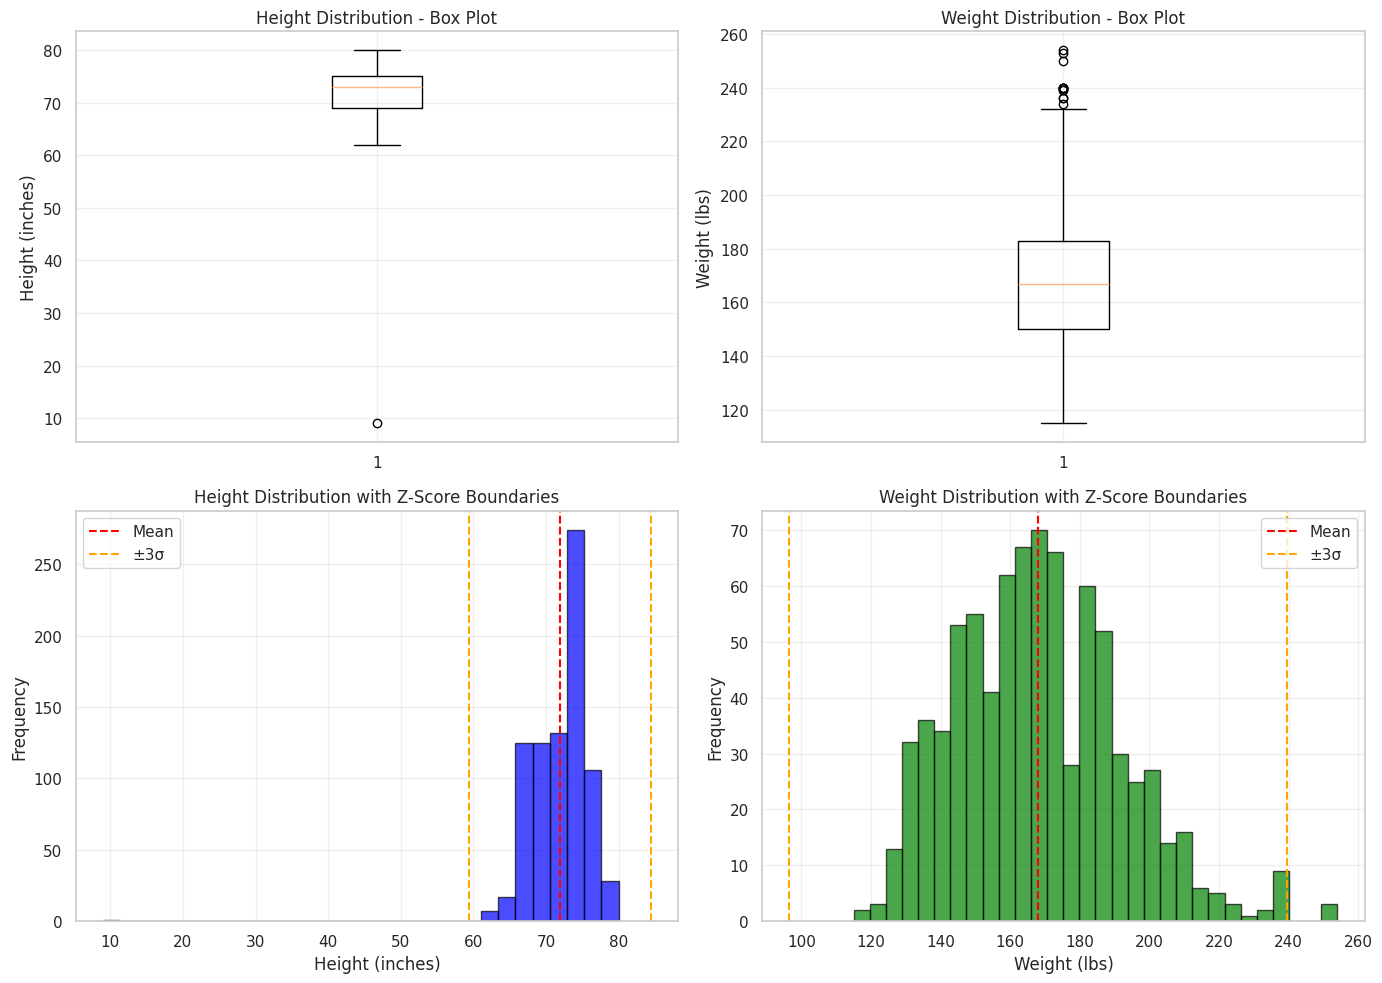

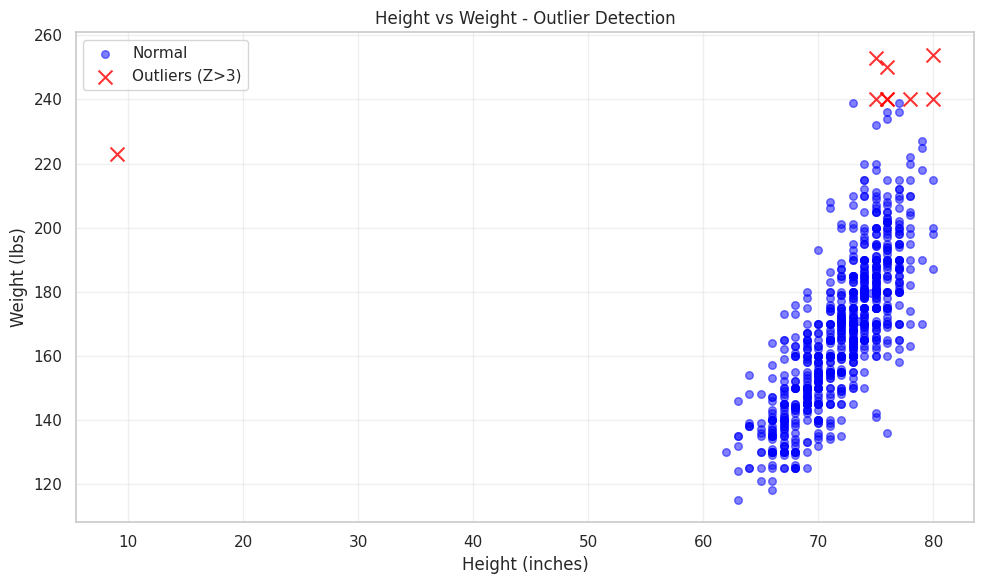

In [9]:
from outliers import detect_outliers_zscore, detect_outliers_iqr, visualize_outliers

# Detect outliers using Z-Score method
print("=== Z-SCORE OUTLIER DETECTION ===\n")
zscore_outliers = detect_outliers_zscore(players_df)

# Detect outliers using IQR method
print("\n=== IQR OUTLIER DETECTION ===\n")
iqr_outliers = detect_outliers_iqr(players_df)

# Visualize outliers
print("\n=== OUTLIER VISUALIZATIONS ===\n")
visualize_outliers(players_df)

**Results Analysis:**

Both detection methods identified a small percentage of outliers (~1.1-1.7% of the dataset). The only outlier that needs fixing is that of the 9 inch height, which is obviously impossible.

Apart from that single instance, some key observations:
- All outliers are **Centers (C)** or **Forward-Centers (F-C)** - positions that naturally have larger physiques
- Height range (73-80") is within realistic WNBA bounds (e.g., Margo Dydek was 7'2" / 86")
- Weight range (236-254 lbs) represents heavier players but remains physiologically plausible
- Outliers cluster together in the scatter plot, showing consistent height-weight relationships

**Conclusion:**

**Only the 9 inch height outlier needs handling**. The others are legitimate extreme values representing the natural variation in elite basketball players, not data errors. The detected outliers are:
1. Position-appropriate (Centers are expected to be taller/heavier)
2. Within realistic bounds for professional women's basketball
3. Consistent with each other (no isolated anomalies)

Removing them would eliminate valid information about player diversity and could bias models against larger athletes. Those outliers will be **retained** for all subsequent analyses.

As for the single outlier, it will be imputed the same way as the missing values were.

In [10]:
# Fix the 9-inch height outlier
# Set it to 0 so it can be imputed using the same ML-based approach as before
players_df.loc[players_df['height'] == 9, 'height'] = 0

print(f"Heights to impute: {(players_df['height'] == 0).sum()}")

players_df = impute_missing_data(players_df)

print("\nOutlier has been imputed using ML-based method")

Heights to impute: 1
Missing Data Imputation - Players

Using ML-based imputation for height and weight

Initial Missing Data Summary:
  Zero heights: 1
  Zero weights: 0


Height statistics before imputation:
count    815.000000
mean      71.940000
std        4.344936
min        0.000000
25%       69.000000
50%       73.000000
75%       75.000000
max       80.000000
Name: height, dtype: float64

Weight statistics before imputation:
count    815.000000
mean     168.027239
std       23.807725
min      115.000000
25%      150.000000
50%      167.000000
75%      183.000000
max      254.000000
Name: weight, dtype: float64
STEP 1: Height Imputation (Random Forest Regression)

Players with missing height: 1

Model Performance on Test Set:
  Mean Absolute Error: 1.51 inches
  R² Score: 0.6944
  5-Fold CV MAE: 1.38 (+/- 0.08)

Predicted heights for 1 players
  Predicted height range: 78.2 - 78.2 inches

STEP 2: Weight Imputation (Random Forest Regression)

No missing weights to impute

Final V

### Teams Dataset

In the data understanding phase, we identified that missing values in the firstRound, semis and finals columns are not errors but indicators that a team did not advance to those playoff stages. To handle the missing values, we'll convert each column to a binary indicator according to whether a team reached that stage of the playoff.

In [11]:
# Convert playoff stage columns to binary indicators
for col in ['firstRound', 'semis', 'finals']:
    teams_df[col] = teams_df[col].notna().astype(int)

#### Outliers

**Outlier Detection and Analysis - Teams Dataset**

We perform outlier detection on team statistics to identify anomalous performance metrics:

**Strategy:**
1. **Z-Score Method**: Identify outliers using standardized scores (|z| > 3)
   - Applied to all numeric team statistics
   - Flags extreme deviations across performance metrics

2. **IQR Method**: Use Interquartile Range for robust outlier detection
   - Q1 - 1.5 × IQR and Q3 + 1.5 × IQR
   - Less sensitive to extreme values

3. **Visualization**: Box plots and scatter plots to visually inspect outliers

**Handling Approach:**
- Document outliers for transparency
- Evaluate if outliers represent exceptional team performance or data errors
- Retain legitimate outliers that represent real historical team performance
- Flag suspicious values for further investigation

=== Z-SCORE OUTLIER DETECTION - TEAMS ===

Z-Score Method (threshold=3):
Total outliers detected: 12
Percentage of dataset: 8.45%

Sample Outliers:


,year,tmID,name,won,lost,attend
0,9,ATL,Atlanta Dream,4,30,141379
1,10,ATL,Atlanta Dream,18,16,120737
36,3,HOU,Houston Comets,24,8,188648
52,10,IND,Indiana Fever,22,12,134964
61,9,LAS,Los Angeles Sparks,20,14,161639
77,2,NYL,New York Liberty,21,11,250565
96,8,PHO,Phoenix Mercury,23,11,131524
97,9,PHO,Phoenix Mercury,16,18,144867
98,10,PHO,Phoenix Mercury,23,11,144884
110,9,SAC,Sacramento Monarchs,18,16,139066



Columns with outliers (count):
attend    3
d_oreb    2
o_fgm     1
o_pf      1
o_pts     1
d_fta     1
o_stl     1
o_blk     1
d_3pa     1
d_3pm     1
dtype: int64

=== IQR OUTLIER DETECTION - TEAMS ===

IQR Method (multiplier=1.5):
Total unique outliers detected: 45
Percentage of dataset: 31.69%

Columns with most outliers:
  finals: 20
  attend: 14
  awayL: 5
  d_asts: 4
  awayW: 4

Sample Outliers:


,year,tmID,name,won,lost,attend
0,9,ATL,Atlanta Dream,4,30,141379
1,10,ATL,Atlanta Dream,18,16,120737
3,2,CHA,Charlotte Sting,18,14,105525
132,1,WAS,Washington Mystics,14,18,244134
133,2,WAS,Washington Mystics,10,22,246667
134,3,WAS,Washington Mystics,17,15,259237
135,4,WAS,Washington Mystics,9,25,238710
136,5,WAS,Washington Mystics,17,17,214448
9,7,CHI,Chicago Sky,5,29,57635
10,8,CHI,Chicago Sky,14,20,66557



=== OUTLIER VISUALIZATIONS - TEAMS ===



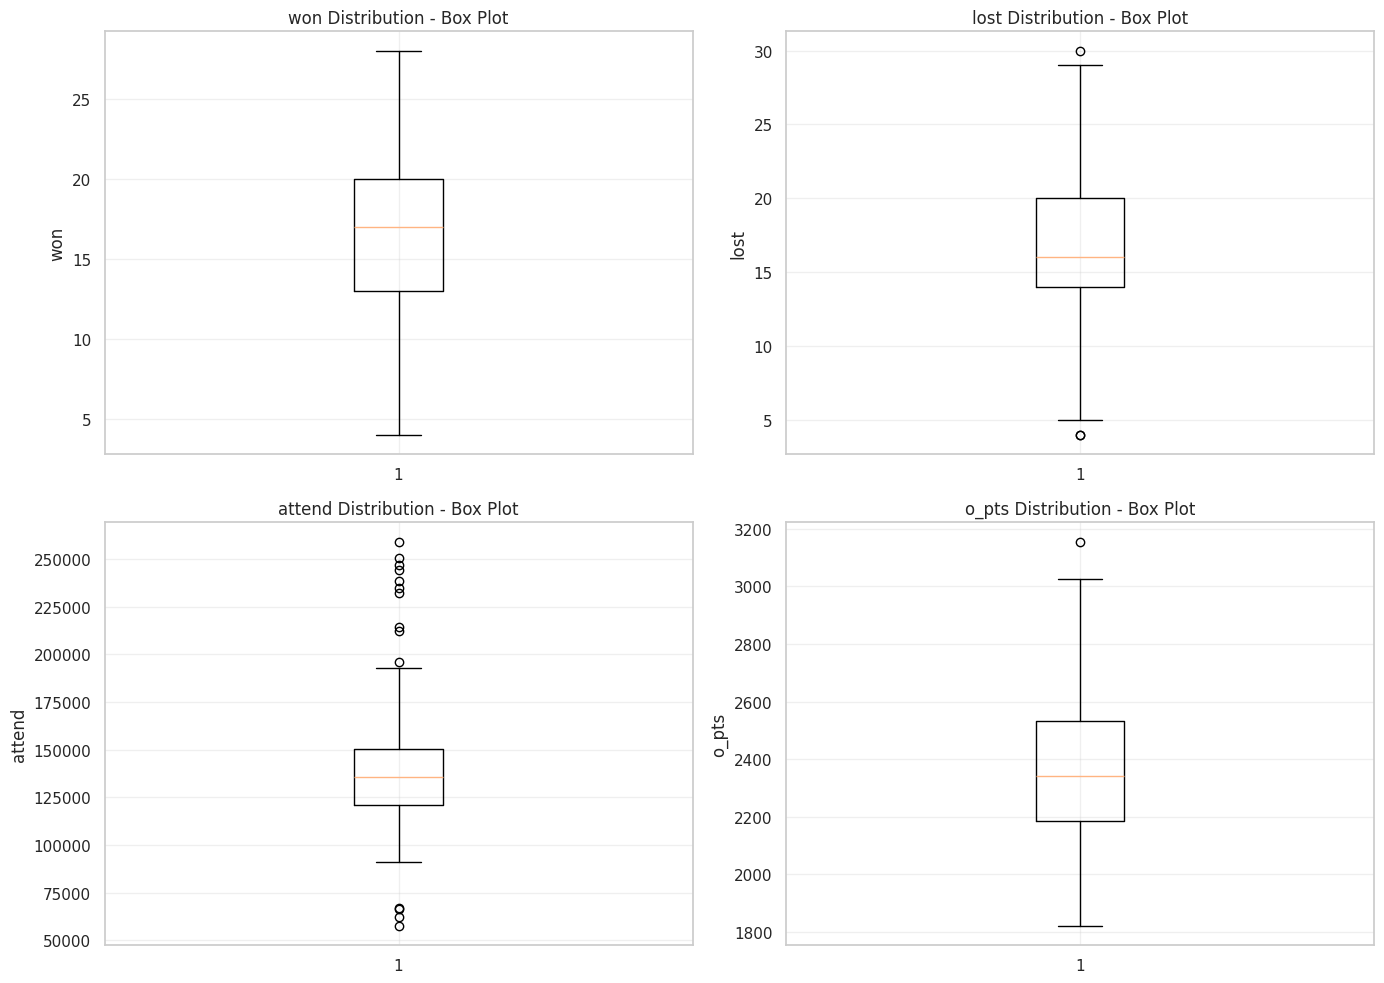

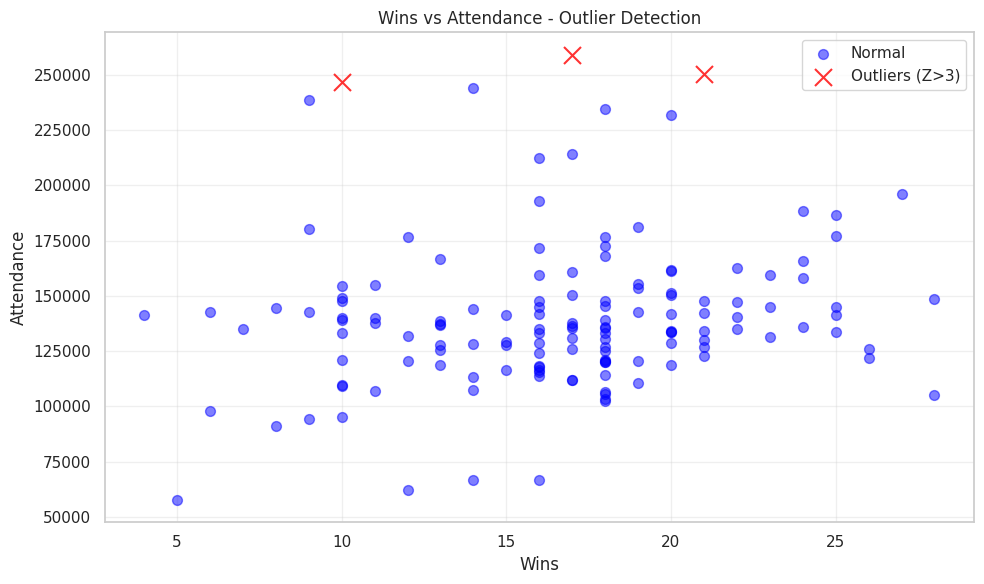

In [12]:
from outliers import detect_outliers_zscore_teams, detect_outliers_iqr_teams, visualize_outliers_teams

# Detect outliers using Z-Score method
print("=== Z-SCORE OUTLIER DETECTION - TEAMS ===\n")
zscore_outliers_teams = detect_outliers_zscore_teams(teams_df)

# Detect outliers using IQR method
print("\n=== IQR OUTLIER DETECTION - TEAMS ===\n")
iqr_outliers_teams = detect_outliers_iqr_teams(teams_df)

# Visualize outliers
print("\n=== OUTLIER VISUALIZATIONS - TEAMS ===\n")
visualize_outliers_teams(teams_df)

**Results Analysis:**

The outlier detection methods identify teams with exceptional or unusual performance metrics across various statistics (attendance, points scored/allowed, rebounds, etc.).

**Key observations:**
- Outliers represent teams with extreme performance (very successful or struggling teams)
- High attendance outliers may represent popular teams or special seasons
- Statistical outliers in scoring/defense metrics reflect exceptional team performance
- Historical context matters - early WNBA seasons may have different baselines

**Conclusion:**

**No outlier removal is required.** The detected outliers represent legitimate historical team performance and should be retained for analysis:
1. Extreme values reflect real team achievements or challenges
2. Outliers provide valuable insights into exceptional seasons
3. Removing them would eliminate important historical variance
4. They are essential for understanding the full spectrum of team performance

The outliers will be **retained** for all subsequent analyses to preserve the complete historical record.

### Players_Teams Dataset

#### Outliers

**Outlier Detection and Analysis - Players Teams Dataset**

We perform outlier detection on player team statistics to identify anomalous performance:

**Strategy:**
1. **Z-Score Method**: Identify outliers using standardized scores (|z| > 3)
   - Applied to key performance statistics (points, rebounds, assists, etc.)
   - Flags extreme deviations from the mean

2. **IQR Method**: Use Interquartile Range for robust outlier detection
   - Q1 - 1.5 × IQR and Q3 + 1.5 × IQR
   - Less sensitive to extreme values

3. **Visualization**: Box plots and scatter plots to visually inspect outliers

**Columns to analyze:**
- Regular season stats: points, rebounds, assists, steals, blocks, minutes
- Efficiency metrics: field goal percentage, free throw percentage
- Playoff statistics (for players who participated)

**Handling Approach:**
- Document outliers for transparency
- Evaluate if outliers represent exceptional performances or data errors
- Retain legitimate outliers that represent real player achievements
- Flag suspicious values for further investigation

=== Z-SCORE OUTLIER DETECTION - PLAYERS_TEAMS ===

Z-Score Method (threshold=3):
Total outliers detected: 130
Percentage of dataset: 6.93%

Sample Outliers:


,playerID,year,tmID,GP,points,rebounds,assists
35,anosini01w,9,MIN,34,314,231,45
36,anosini01w,10,MIN,30,396,222,81
51,augusse01w,7,MIN,34,744,128,50
52,augusse01w,8,MIN,34,769,136,79
59,azzije01w,2,UTA,32,276,98,171
74,baranel01w,2,MIA,32,378,191,63
76,baranel01w,5,NYL,34,394,246,67
126,birdsu01w,3,SEA,32,461,83,191
127,birdsu01w,4,SEA,34,420,113,221
128,birdsu01w,5,SEA,34,439,106,184



Columns with outliers (count):
blocks         44
assists        37
ftMade         30
rebounds       22
ftAttempted    22
steals         19
points         10
fgMade          8
fgAttempted     5
turnovers       2
dtype: int64

=== IQR OUTLIER DETECTION - PLAYERS_TEAMS ===

IQR Method (multiplier=1.5):
Total unique outliers detected: 276
Percentage of dataset: 14.71%

Columns with most outliers:
  blocks: 156
  assists: 77
  ftMade: 64
  ftAttempted: 57
  rebounds: 29

Sample Outliers:


,playerID,year,tmID,GP,points,rebounds,assists
1538,stepama01w,2,PHO,32,334,201,41
1527,staleda01w,7,HOU,34,250,75,133
1539,stepama01w,6,PHO,15,162,80,23
1046,mcwilta01w,1,ORL,32,438,244,54
1047,mcwilta01w,2,ORL,32,403,243,69
1049,mcwilta01w,4,CON,34,354,227,49
1050,mcwilta01w,5,CON,34,413,244,63
1052,mcwilta01w,7,CON,32,410,306,80
1053,mcwilta01w,8,LAS,29,321,170,49
1565,suttota01w,2,CHA,29,196,129,11



=== OUTLIER VISUALIZATIONS - PLAYERS_TEAMS ===



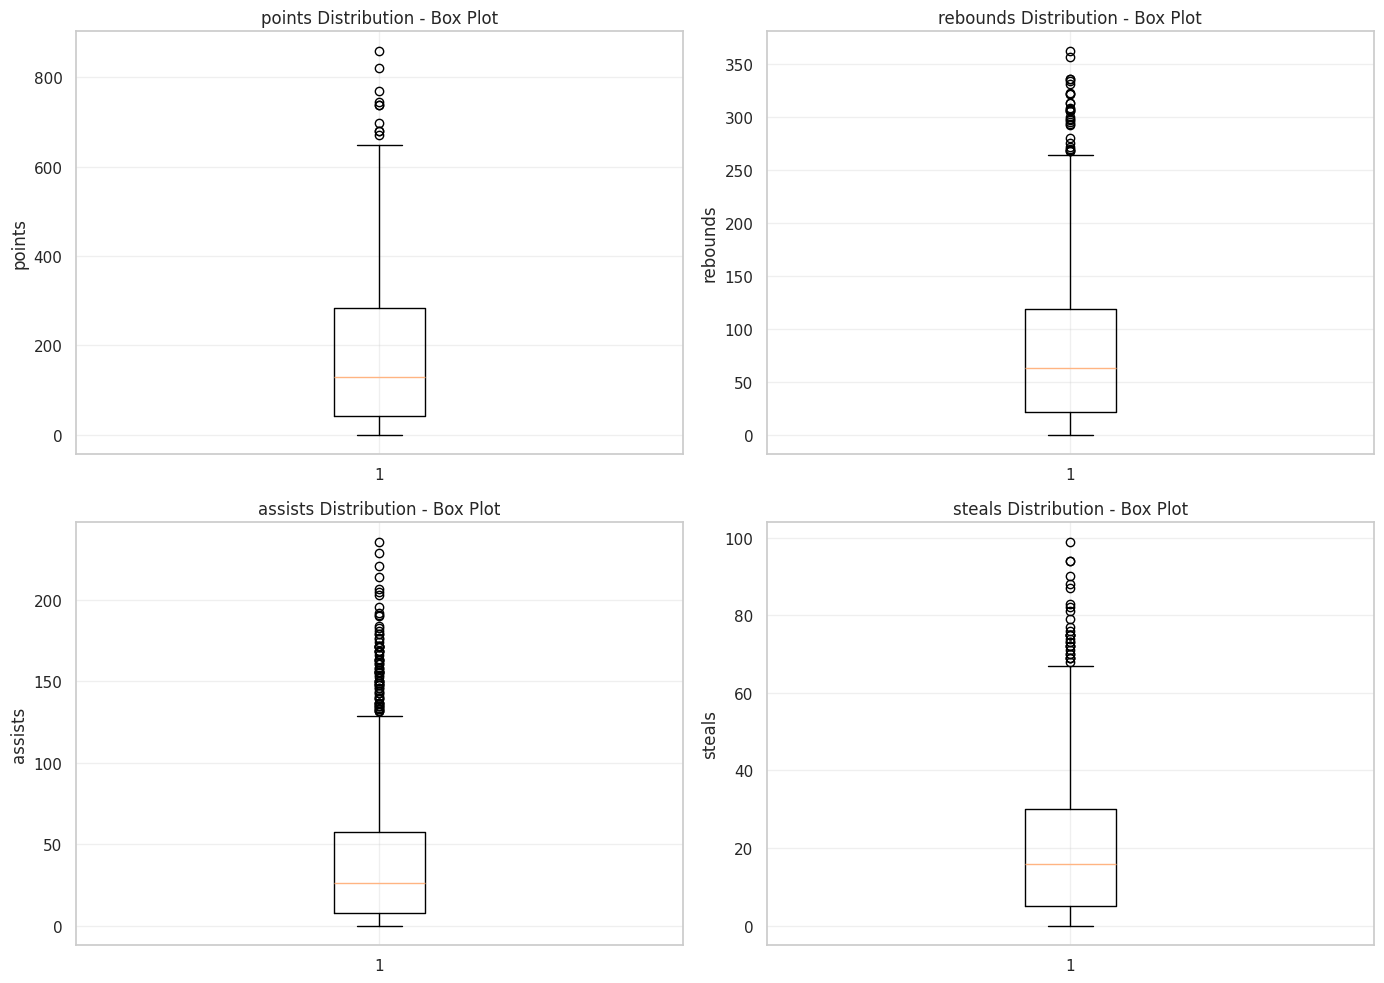

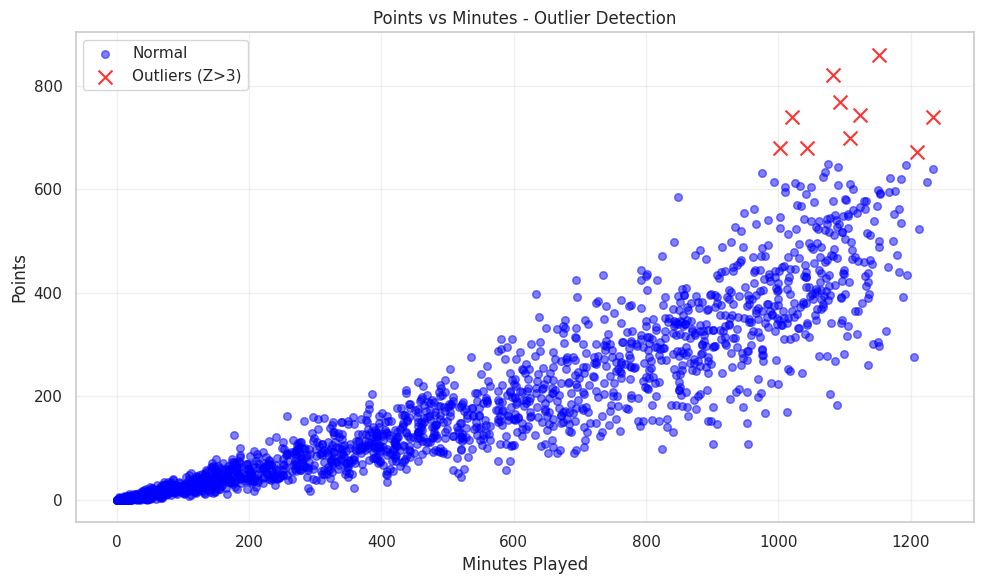

In [13]:
from outliers import detect_outliers_zscore_players_teams, detect_outliers_iqr_players_teams, visualize_outliers_players_teams

# Detect outliers using Z-Score method
print("=== Z-SCORE OUTLIER DETECTION - PLAYERS_TEAMS ===\n")
zscore_outliers_pt = detect_outliers_zscore_players_teams(players_teams_df)

# Detect outliers using IQR method
print("\n=== IQR OUTLIER DETECTION - PLAYERS_TEAMS ===\n")
iqr_outliers_pt = detect_outliers_iqr_players_teams(players_teams_df)

# Visualize outliers
print("\n=== OUTLIER VISUALIZATIONS - PLAYERS_TEAMS ===\n")
visualize_outliers_players_teams(players_teams_df)

**Results Analysis:**

The outlier detection methods identify player-team season performances with exceptional statistics across various metrics (points, rebounds, assists, steals, blocks, minutes).

**Key observations:**
- Outliers represent players with exceptional season performances (All-Stars, MVP candidates)
- High values in counting stats (points, rebounds, assists) often correlate with high minutes played
- Statistical outliers reflect dominant individual performances
- Some outliers may represent partial season data or unique circumstances

**Conclusion:**

**No outlier removal is required.** The detected outliers represent legitimate exceptional player performances and should be retained for analysis:
1. Extreme values reflect real player achievements and elite performances
2. Outliers provide valuable insights into what constitutes exceptional play
3. Removing them would eliminate important information about star players
4. They are essential for understanding the full spectrum of player performance
5. Many outliers likely represent award-winning seasons or Hall of Fame performances

The outliers will be **retained** for all subsequent analyses to preserve the complete performance record and enable proper analysis of exceptional talent.

### Awards_players Dataset

In the data understanding phase we identified that there were two different names for the Kim Perrot Sportsmanship Award.

In [14]:
awards_players_df['award'] = awards_players_df['award'].replace('Kim Perrot Sportsmanship', 'Kim Perrot Sportsmanship Award')

### Feature Engineering

In [15]:
# Total wins and losses (regular season + playoff)
coaches_df["total_w"] = coaches_df["won"] + coaches_df["post_wins"]
coaches_df["total_l"] = coaches_df["lost"] + coaches_df["post_losses"]

coaches_df["total_games"] = coaches_df["total_w"] + coaches_df['total_l']
coaches_df["total_winratio"] = coaches_df["total_w"] / coaches_df["total_games"]

In [16]:
# Player per-game stats
per_game_stats = {
    "ppg": "points",
    "apg": "assists",
    "rpg": "rebounds",
    "spg": "steals",
    "bpg": "blocks",
    "mpg": "minutes",
    "pfpg": "PF",
    "dqpg": "dq",
    "gspg": "GS"
}

for new_col, name in per_game_stats.items():
    players_teams_df[new_col] = players_teams_df[name] / players_teams_df["GP"]

In [17]:
# Playoff per-game stats
post_per_game_stats = {
    "post_ppg": "PostPoints",
    "post_apg": "PostAssists",
    "post_rpg": "PostRebounds",
    "post_spg": "PostSteals",
    "post_bpg": "PostBlocks",
    "post_mpg": "PostMinutes",
    "post_pfpg": "PostPF",
    "post_dqpg": "PostDQ",
    "post_gspg": "PostGS"
}

for new_col, name in post_per_game_stats.items():
    players_teams_df[new_col] = players_teams_df[name] / players_teams_df["PostGP"]

In [18]:
# Weighted steals + blocks + dRebounds per game -> defensive feature
# steals > blocks > dRebounds
players_teams_df["sbdRpg"] = (players_teams_df["steals"] + 0.75 * players_teams_df["blocks"] + 0.50 * players_teams_df["dRebounds"]) / players_teams_df["GP"]

In [19]:
# Assist to turnover Ratio
players_teams_df["ast_to"] = players_teams_df["assists"] / players_teams_df["turnovers"]
players_teams_df["post_ast_to"] = players_teams_df["PostAssists"] / players_teams_df["PostTurnovers"]


In [20]:
# Player Efficiency Rating (PER)
players_teams_df["NBA_PER"] = (players_teams_df['points'] + players_teams_df['rebounds']+ players_teams_df['assists'] + players_teams_df['steals'] + players_teams_df['blocks']
  - ((players_teams_df['fgAttempted'] - players_teams_df['fgMade']) + (players_teams_df['ftAttempted'] - players_teams_df['ftMade']) + players_teams_df['turnovers'])
) / players_teams_df["GP"]

In [21]:
# True Shooting Percentage - how efficiently a player converts their scoring opportunities
players_teams_df["ts_pct"] = players_teams_df['points'] / (2 * (players_teams_df["fgAttempted"] + (0.44 * players_teams_df["ftAttempted"])))

players_teams_df['post_ts_pct'] = players_teams_df['PostPoints'] / (
    2 * (players_teams_df['PostfgAttempted'] + 0.44 * players_teams_df['PostftAttempted'])
)

In [22]:
# Effective Field Goal Percentage - adjusts FG% to account for the fact that 3P count for three points
players_teams_df['efg_pct'] = (players_teams_df['fgMade'] + (0.5 * players_teams_df['threeMade'])) / players_teams_df['fgAttempted']
players_teams_df['efg_pct'] = players_teams_df['efg_pct'].fillna(0)

# Maybe a problem: shooters with high percentage success rates, can have eFG% > 100%
# players_teams_df[players_teams_df['efg_pct'] > 1][['efg_pct','ts_pct']]1

players_teams_df['post_efg_pct'] = (
    players_teams_df['PostfgMade'] + 0.5 * players_teams_df['PostthreeMade']
) / players_teams_df['PostfgAttempted']

In [23]:
# Rebound Rate -> how effective a player is at gaining possesion
# after missed field goal or free throw

# Merge to get team stats
x = players_teams_df.merge(
    teams_df[['year','tmID','o_reb','d_reb','min']],  # team totals + minutes played
    on=['year','tmID'], how='left', suffixes=('', '_team')
)

players_teams_df['REB_rate'] = (
    players_teams_df['rebounds'] * (x['min'] / 5) /
    (players_teams_df['minutes'] * (x['o_reb'] + x['d_reb']))
)

In [24]:
# teams avg player NBA PER
team_per = (
    players_teams_df
    .groupby(['year', 'tmID'])['NBA_PER']
    .mean()
    .reset_index()
)

# merge into teams_df
teams_df = teams_df.merge(
    team_per,
    on=['year', 'tmID'],
    how='left'
)

In [25]:
# top 3 PER per team per year
top3_per = (
    teams_df
    .sort_values(['year','tmID','NBA_PER'], ascending=[True, True, False])
    .groupby(['year','tmID'])
    .head(3)  # take top 3 PER players
    .groupby(['year','tmID'])['NBA_PER']
    .mean()
    .reset_index()
    .rename(columns={'NBA_PER':'top3_per'})
)

# Merge into teams_df
teams_df = teams_df.merge(top3_per, on=['year','tmID'], how='left')

In [26]:
# Teams Win/Loss metrics
teams_df['win_pct'] = teams_df['won'] / teams_df['GP']
teams_df['home_win_pct'] = teams_df['homeW'] / (teams_df['homeW'] + teams_df['homeL'])
teams_df['away_win_pct'] = teams_df['awayW'] / (teams_df['awayW'] + teams_df['awayL'])
teams_df['conf_win_pct'] = teams_df['confW'] / (teams_df['confW'] + teams_df['confL'])

teams_df = teams_df.sort_values(['tmID', 'year'])
teams_df['delta_win_pct'] = teams_df.groupby('tmID')['win_pct'].diff().fillna(0)

In [27]:
# Teams Win%
players_teams_df = players_teams_df.merge(
    teams_df[['year', 'tmID', 'win_pct']],
    on=['year', 'tmID'],
    how='left'
)

players_teams_df.rename(columns={'win_pct': 'team_win_pct'}, inplace=True)

In [28]:
# Attendance (maybe not relevant)
teams_df['avg_attendance'] = teams_df['attend'] / teams_df['GP']

In [29]:
# Teams Per game Stats
teams_df['ppg'] = teams_df['o_pts'] / teams_df['GP']
teams_df['papg'] = teams_df['d_pts'] / teams_df['GP'] # points allowed
teams_df['pdiffpg'] = teams_df['ppg'] - teams_df['papg'] # points diff
teams_df['stlpg'] = teams_df['o_stl'] / teams_df['GP']
teams_df['blkpg'] = teams_df['o_blk'] / teams_df['GP']

# weighted defensive -> steals > blocks > defensive reb
teams_df["sbdRpg"] = (teams_df["o_stl"] + 0.75 * teams_df["o_blk"] + 0.50 * teams_df["o_dreb"]) / teams_df["GP"]

In [30]:
# Assist to turnover Ratio (teams)
teams_df['ast_to'] = teams_df['o_asts'] / teams_df['o_to']

##### Rolling features

In [31]:
# important to sort by year to get rolling correctly
players_teams_sorted_df = players_teams_df.sort_values(["playerID", "year"]).copy()

In [32]:
# Define stats for rolling calculation
players_rolling_stats = (
    list(per_game_stats.keys()) + 
    ["ast_to", "efg_pct", "ts_pct", "NBA_PER", "sbdRpg"]
)

# Last 3 seasons + Last 5 seasons
for col in players_rolling_stats:
    for window in [3,5]:
        players_teams_sorted_df[f"{col}_rolling{window}"] = players_teams_sorted_df.groupby("playerID")[col].rolling(window=window, min_periods=1).mean().reset_index(0, drop=True)

In [33]:
# improvements/deltas -> maybe useful for most improved player
for col in players_rolling_stats:
    players_teams_sorted_df[f"delta_{col}"] = players_teams_sorted_df[col] - players_teams_sorted_df.groupby("playerID")[col].shift(1)

In [34]:
teams_sorted_df = teams_df.sort_values(["tmID", "year"]).copy()

In [35]:
teams_rolling_stats = [
    'ppg',
    'papg',
    'stlpg',
    'blkpg',
    "sbdRpg",
    'win_pct',
    "ast_to"
]

for col in teams_rolling_stats:
    for window in [3,5]:
        teams_sorted_df[f"{col}_rolling{window}"] = teams_sorted_df.groupby('tmID')[col].rolling(window, min_periods=1).mean().reset_index(0, drop=True)

In [36]:
# !important merge to original df 
players_teams_df = players_teams_df.merge(
    players_teams_sorted_df[
        ["playerID", "year"] + 
        [f"{c}_rolling{w}" for c in players_rolling_stats for w in [3,5]] +
        [f"delta_{c}" for c in players_rolling_stats]
    ],
    on=["playerID", "year"],
    how="left"
)

teams_df = teams_df.merge(
    teams_sorted_df[
        ['tmID', 'year'] + 
        [f"{col}_rolling{w}" for col in teams_rolling_stats for w in [3,5]]
    ],
    on=['tmID', 'year'],
    how='left'
)

In [37]:
print(f"Number of features on teams_df: {len(teams_df.columns)}\n")
print(teams_df.columns)

Number of features on teams_df: 80

Index(['year', 'tmID', 'confID', 'rank', 'playoff', 'firstRound', 'semis',
       'finals', 'name', 'o_fgm', 'o_fga', 'o_ftm', 'o_fta', 'o_3pm', 'o_3pa',
       'o_oreb', 'o_dreb', 'o_reb', 'o_asts', 'o_pf', 'o_stl', 'o_to', 'o_blk',
       'o_pts', 'd_fgm', 'd_fga', 'd_ftm', 'd_fta', 'd_3pm', 'd_3pa', 'd_oreb',
       'd_dreb', 'd_reb', 'd_asts', 'd_pf', 'd_stl', 'd_to', 'd_blk', 'd_pts',
       'won', 'lost', 'GP', 'homeW', 'homeL', 'awayW', 'awayL', 'confW',
       'confL', 'min', 'attend', 'arena', 'NBA_PER', 'top3_per', 'win_pct',
       'home_win_pct', 'away_win_pct', 'conf_win_pct', 'delta_win_pct',
       'avg_attendance', 'ppg', 'papg', 'pdiffpg', 'stlpg', 'blkpg', 'sbdRpg',
       'ast_to', 'ppg_rolling3', 'ppg_rolling5', 'papg_rolling3',
       'papg_rolling5', 'stlpg_rolling3', 'stlpg_rolling5', 'blkpg_rolling3',
       'blkpg_rolling5', 'sbdRpg_rolling3', 'sbdRpg_rolling5',
       'win_pct_rolling3', 'win_pct_rolling5', 'ast_to_rolling3'

In [38]:
print(f"Number of features on teams_df: {len(players_teams_df.columns)}\n")
print(players_teams_df.columns)

Number of features on teams_df: 112

Index(['playerID', 'year', 'stint', 'tmID', 'GP', 'GS', 'minutes', 'points',
       'oRebounds', 'dRebounds',
       ...
       'delta_bpg', 'delta_mpg', 'delta_pfpg', 'delta_dqpg', 'delta_gspg',
       'delta_ast_to', 'delta_efg_pct', 'delta_ts_pct', 'delta_NBA_PER',
       'delta_sbdRpg'],
      dtype='object', length=112)


In [39]:
# clean inf
players_teams_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [40]:
# clean NaN
teams_df.fillna(0, inplace=True)
players_teams_df.fillna(0, inplace=True)